--- DISERTAȚIE: Isolation Forest cu PRAG DINAMIC [ACCELERAT PYTORCH/NVIDIA CUDA] ---
PyTorch version: 2.11.0+cu130
CUDA available: True
[*] Date încărcate pentru antrenare (Benigne 2017): 345659 rânduri.
[*] Date încărcate pentru testare (Total 2017): 100250 rânduri.

Începe antrenarea structurală a arborilor...

Execuție inferență paralelă pe GPU (RTX 5070 Ti via PyTorch)...
Inferență pe GPU finalizată în 0.7009s

1. RAPORT FINAL DE AUDIT:
SISTEM AUDIT SSH - REZULTATE ISOLATION FOREST (ACCELERAT GPU/PYTORCH)
Scor AUC (Capacitate de discriminare): 0.5748
              precision    recall  f1-score   support

      Normal       0.91      0.69      0.78     86415
    Anomalie       0.22      0.56      0.32     13835

    accuracy                           0.67    100250
   macro avg       0.57      0.62      0.55    100250
weighted avg       0.81      0.67      0.72    100250


2. GENERARE MATRICE DE CONFUZIE...


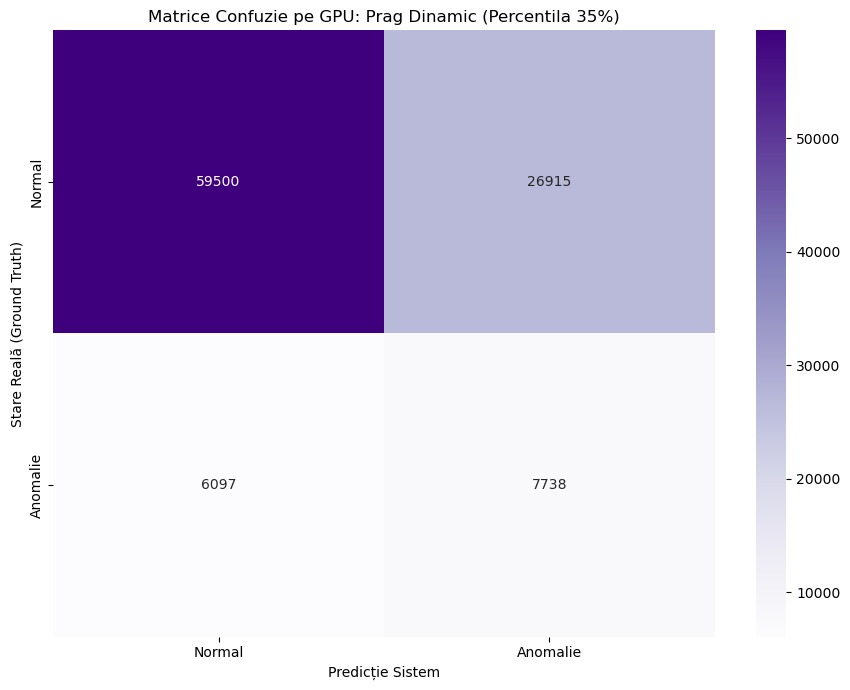


3. GENERARE CURBA ROC...


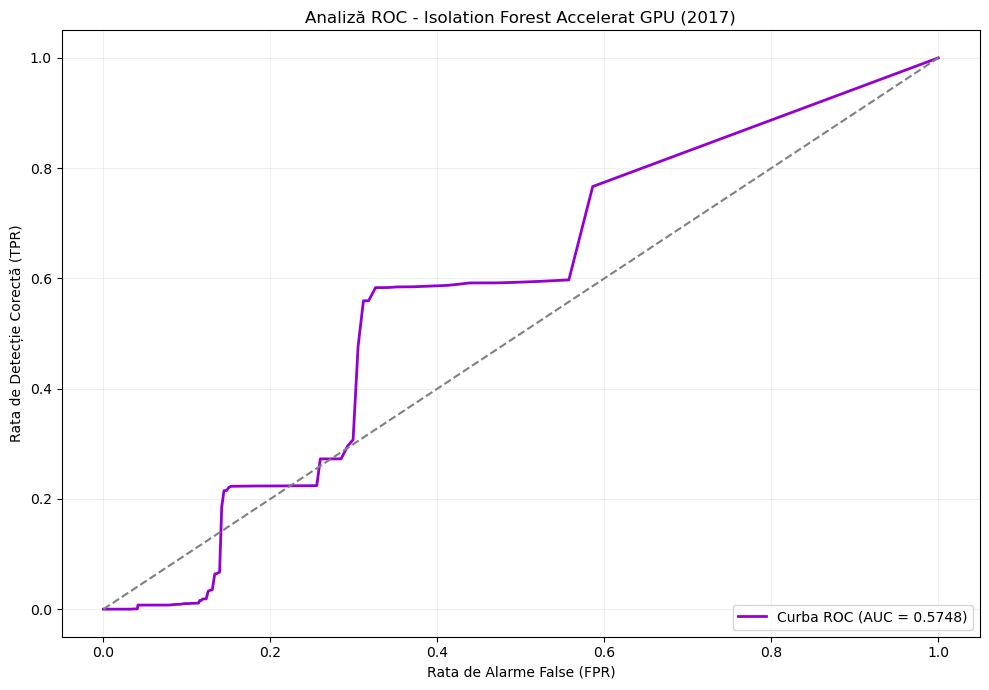

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, roc_curve, auc as sk_auc, classification_report

prepro_path = r'D:\disertatie\preprocesare_anomalii_2017'
model_save_path = r'D:\disertatie\modele_2017\Isolation_Forest'
rezultate_path = r'D:\disertatie\rezultate_2017\Isolation_Forest'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- DISERTAȚIE: Isolation Forest cu PRAG DINAMIC [ACCELERAT PYTORCH/NVIDIA CUDA] ---")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


X_train_tensor = torch.load(os.path.join(prepro_path, 'X_train_anomalii.pt'), map_location=device)
X_test_tensor = torch.load(os.path.join(prepro_path, 'X_test_anomalii.pt'), map_location=device)
y_test_tensor = torch.load(os.path.join(prepro_path, 'y_test_anomalii.pt'), map_location=device)
print(f"[*] Date încărcate pentru antrenare (Benigne 2017): {X_train_tensor.shape[0]} rânduri.")
print(f"[*] Date încărcate pentru testare (Total 2017): {X_test_tensor.shape[0]} rânduri.")
X_train_cpu = X_train_tensor.cpu().numpy().astype(np.float32)
X_test_cpu = X_test_tensor.cpu().numpy().astype(np.float32)
y_test_cpu = y_test_tensor.cpu().numpy().astype(np.int32)

iso_forest = IsolationForest(
    n_estimators=100, 
    contamination=0.15, 
    random_state=42,
    max_samples=256,
    n_jobs=-1
)

print("\nÎncepe antrenarea structurală a arborilor...")
start_time = time.time()
iso_forest.fit(X_train_cpu)


def predict_iforest_pytorch(iforest_model, X_tensor):
    n_samples = X_tensor.shape[0]
    n_estimators = len(iforest_model.estimators_)
    paths_length = torch.zeros((n_samples, n_estimators), device=device)
    
    for i, estimator in enumerate(iforest_model.estimators_):
        tree = estimator.tree_
        left_children = torch.tensor(tree.children_left, dtype=torch.long, device=device)
        right_children = torch.tensor(tree.children_right, dtype=torch.long, device=device)
        features = torch.tensor(tree.feature, dtype=torch.long, device=device)
        thresholds = torch.tensor(tree.threshold, dtype=torch.float32, device=device)
        
        node_indicator = torch.zeros(n_samples, dtype=torch.long, device=device)
        depths = torch.zeros(n_samples, device=device)
        
        while True:
            current_features = features[node_indicator]
            is_leaf = current_features == -2
            if torch.all(is_leaf):
                break
                
            going_left = X_tensor[torch.arange(n_samples), current_features] <= thresholds[node_indicator]
            
            node_indicator = torch.where(
                is_leaf, 
                node_indicator, 
                torch.where(going_left, left_children[node_indicator], right_children[node_indicator])
            )
            depths = torch.where(is_leaf, depths, depths + 1)
            
        paths_length[:, i] = depths
        
    mean_paths = torch.mean(paths_length, dim=1)
    
    def c_factor(n):
        if n <= 1:
            return 0.0
        if n == 2:
            return 1.0
        return 2.0 * (np.log(n - 1) + 0.5772156649) - (2.0 * (n - 1) / n)
        
    c = c_factor(iforest_model.max_samples_)
    scores = -torch.pow(2.0, - (mean_paths / (c + 1e-10)))
    return scores

print("\nExecuție inferență paralelă pe GPU (RTX 5070 Ti via PyTorch)...")
start_inference = time.time()
with torch.no_grad():
    decision_scores_tensor = predict_iforest_pytorch(iso_forest, X_test_tensor)
    decision_scores = decision_scores_tensor.cpu().numpy()
print(f"Inferență pe GPU finalizată în {time.time() - start_inference:.4f}s")

percentila_dorita = 35
prag_dinamic = np.percentile(decision_scores, percentila_dorita)

y_pred_np = np.array([1 if x < prag_dinamic else 0 for x in decision_scores], dtype=np.int32)

fpr, tpr, _ = roc_curve(y_test_cpu, -decision_scores)
roc_auc = sk_auc(fpr, tpr)

report = classification_report(y_test_cpu, y_pred_np, target_names=['Normal', 'Anomalie'])
full_report_text = f"SISTEM AUDIT SSH - REZULTATE ISOLATION FOREST (ACCELERAT GPU/PYTORCH)\n"
full_report_text += f"Scor AUC (Capacitate de discriminare): {roc_auc:.4f}\n"
full_report_text += "="*50 + "\n"
full_report_text += report

print("\n1. RAPORT FINAL DE AUDIT:")
print(full_report_text)

with open(os.path.join(rezultate_path, 'raport_final_iso_forest_gpu.txt'), 'w') as f:
    f.write(full_report_text)

print("\n2. GENERARE MATRICE DE CONFUZIE...")
plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test_cpu, y_pred_np)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.title(f'Matrice Confuzie pe GPU: Prag Dinamic (Percentila {percentila_dorita}%)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_iso_forest_gpu.png'), dpi=300)
plt.show()

print("\n3. GENERARE CURBA ROC...")
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkviolet', lw=2, label=f'Curba ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.ylabel('Rata de Detecție Corectă (TPR)')
plt.xlabel('Rata de Alarme False (FPR)')
plt.title('Analiză ROC - Isolation Forest Accelerat GPU (2017)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_iso_forest_gpu.png'), dpi=300)
plt.show()

with open(os.path.join(model_save_path, 'model_iso_forest_dinamic_gpu.pkl'), 'wb') as f:
    pickle.dump(iso_forest, f)


